In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy import stats
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
from itertools import combinations
import json
import random
from adjustText import adjust_text
import plotly.graph_objects as go
from collections import Counter
from matplotlib.patches import Patch

sc.settings.verbosity = 2

In [2]:
import plotly.io as pio
pio.renderers.default = 'notebook'

# Load in TF-associated networks

In [3]:
# MYOD1
path1 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/MYOD_network_1storder_300.csv"
mdf = pd.read_csv(path1, index_col=0)
print(mdf.shape)
display(mdf.head())


# PRRX1
path2 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/PRRX1_network_1storder_300.csv"
pdf = pd.read_csv(path2, index_col=0)
print(pdf.shape)
display(pdf.head())

(545, 545)


,MYOD1,CD99,KDM1A,PDK4,CALCR,HOXA11,MEOX1,CREBBP,SOX8,IFRD1,...,INS,ENSG00000255071,EID1,SCX,DUX4,PECAM1,MYMX,MYH4,H3-7,DACH1
MYOD1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
CD99,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
KDM1A,1,0,1,1,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
PDK4,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
CALCR,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


(196, 196)


,PRRX1,COPZ2,TFAP2B,METTL13,DCN,SNAI2,VIM,CD44,CDH1,PHF23,...,COL5A2,POU5F1,VGLL3,EBF2,TWIST2,BGLAP,FOXD1,HOXB7,SCX,GTF2I
PRRX1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
COPZ2,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
TFAP2B,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
METTL13,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DCN,1,0,0,0,0,1,1,1,1,0,...,1,0,0,0,0,1,0,0,1,0


## Make graphs

In [7]:
# MYOD1
GM = nx.from_pandas_adjacency(mdf, create_using=nx.Graph) # keeps self-loops
GM.remove_edges_from(nx.selfloop_edges(GM)) # remove self-loops

print(f"MYOD1:\nN nodes: {GM.number_of_nodes()}\nN edges: {GM.number_of_edges()}")

n_edges = GM.number_of_edges()
n_nodes = GM.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(GM)}')
print(f'N connected components: {nx.number_connected_components(GM)}')
print(f'Largest connected components has {len(max(nx.connected_components(GM), key=len))} nodes\n')



# PRRX1
GP = nx.from_pandas_adjacency(pdf, create_using=nx.Graph) # keeps self-loops
GP.remove_edges_from(nx.selfloop_edges(GP)) # remove self-loops

print(f"\nPRRX1:\nN nodes: {GP.number_of_nodes()}\nN edges: {GP.number_of_edges()}")

n_edges = GP.number_of_edges()
n_nodes = GP.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(GP)}')
print(f'N connected components: {nx.number_connected_components(GP)}')
print(f'Largest connected components has {len(max(nx.connected_components(GP), key=len))} nodes')



## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
prrx_nodes = list(GP.nodes())

MYOD1:
N nodes: 545
N edges: 29898
Graph density: 0.2017

Is connected? True
N connected components: 1
Largest connected components has 545 nodes


PRRX1:
N nodes: 196
N edges: 4055
Graph density: 0.2122

Is connected? True
N connected components: 1
Largest connected components has 196 nodes


In [5]:
## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
print(len(myod_nodes))

prrx_nodes = list(GP.nodes())
print(len(prrx_nodes))

545
196


# Load in adata

In [6]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.45 GB, difference +2.45 GB
CPU times: user 504 ms, sys: 1.46 s, total: 1.97 s
Wall time: 6.39 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning:

The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`



AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [6]:
# Load TFs
fpath = "../../resources/HumanTF_v_1.01.csv"

tdf = pd.read_csv(fpath)

tdf = tdf[['HGNC symbol', 'Is TF?']]
tdf = tdf.rename(columns={'HGNC symbol': 'gene_name', 'Is TF?': 'is_tf'})
tdf = tdf[tdf['is_tf'] == 'Yes']
tdf = tdf.drop_duplicates(subset='gene_name')
display(tdf.head())

# extract unique TFs
tf_list = tdf['gene_name'].unique()
print(len(tf_list))

tf_list = [g for g in tf_list if g in adata.var_names]

print(len(tf_list))

,gene_name,is_tf
0,TFAP2A,Yes
1,TFAP2B,Yes
2,TFAP2C,Yes
3,TFAP2D,Yes
4,TFAP2E,Yes


1639
1358


MYOD1 subgraph

Condition-specific subgraph 
* only keep detected nodes (min_counts = 10)
* only keep nodes expressed in >= 10% of cells
* co-expression --> edge weights (where weight = 0, no edge)

In [7]:
conditions_to_keep = ['Control', 'mmMYOD1']

fdata = adata[adata.obs['pooled_condition'].isin(conditions_to_keep), :].copy()
print(fdata.shape)

(9157, 25126)


In [8]:
# filter genes
fdata.X = fdata.layers['raw_counts'].copy()

sc.pp.filter_genes(fdata, min_counts=10) # param used for original processing

sc.pp.normalize_total(fdata, target_sum=1e4)
fdata.layers['CP10K'] = fdata.X.copy()

sc.pp.log1p(fdata)
fdata.layers['log_norm_new'] = fdata.X.copy()
fdata

filtered out 2091 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:01)


AnnData object with n_obs × n_vars = 9157 × 23035
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std

# Detected genes

In [9]:
### Which genes are present in adata?
# MYOD1
gene_names = set(fdata.var_names)
gene_ids = set(fdata.var['gene_id'])

myod_genes = [
    g for g in myod_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_myod_genes = list(set(myod_nodes) - set(myod_genes))

print(f"N myod nodes in fdata: {len(myod_genes)}")
print(f"{len(missing_myod_genes)} genes not detected.\n")


# PRRX1
prrx_genes = [
    g for g in prrx_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_prrx_genes = list(set(prrx_nodes) - set(prrx_genes))

print(f"N prrx1 nodes in fdata: {len(prrx_genes)}")
print(f"{len(missing_prrx_genes)} genes not detected.")

N myod nodes in fdata: 431
114 genes not detected.

N prrx1 nodes in fdata: 176
20 genes not detected.


In [10]:
### genes expressed in greater than 10% of cells in either condition
pct_exp_thresh = 0.10

print(f"Nodes (genes) expressed in ≥ {pct_exp_thresh*100:.0f}% of cells in either condition...")

## --------- MYOD1 genes ---------
# Boolean matrix: cells × genes
fdata.X = fdata.layers['raw_counts'].copy()

X = fdata[:, myod_genes].X > 0

# Convert to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

df = pd.DataFrame(X, index=fdata.obs['pooled_condition'], columns=myod_genes)

# Compute fraction per condition
frac_by_condition = df.groupby(level=0, observed=True).mean()

# Keep genes passing threshold in ANY condition
myod_genes_robust = frac_by_condition.columns[(frac_by_condition >= pct_exp_thresh).any(axis=0)].tolist()
print(f"\nN MYOD1 genes: {len(myod_genes_robust)}")
print(f"% of detected nodes: {(len(myod_genes_robust) / len(myod_genes))*100:.1f}%")
print(f"% of total nodes: {(len(myod_genes_robust) / len(myod_nodes))*100:.1f}%")


## --------- PRRX1 genes ---------
X = fdata[:, prrx_genes].X > 0

# Convert to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

df = pd.DataFrame(X, index=fdata.obs['pooled_condition'], columns=prrx_genes)

# Compute fraction per condition
frac_by_condition = df.groupby(level=0, observed=True).mean()

# Keep genes passing threshold in ANY condition
prrx_genes_robust = frac_by_condition.columns[(frac_by_condition >= pct_exp_thresh).any(axis=0)].tolist()
print(f"\nN PRRX1 genes: {len(prrx_genes_robust)}")
print(f"% of detected nodes: {(len(prrx_genes_robust) / len(prrx_genes))*100:.1f}%")
print(f"% of total nodes: {(len(prrx_genes_robust) / len(prrx_nodes))*100:.1f}%")

Nodes (genes) expressed in ≥ 10% of cells in either condition...

N MYOD1 genes: 269
% of detected nodes: 62.4%
% of total nodes: 49.4%

N PRRX1 genes: 127
% of detected nodes: 72.2%
% of total nodes: 64.8%


# Build baseline subgraphs

In [11]:
# Baseline
print("Baseline subgraphs...")

BGM = GM.subgraph(myod_genes_robust).copy()
n_edges = BGM.number_of_edges()
n_nodes = BGM.number_of_nodes()
print(f"\nMYOD1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(BGM)}')
print(f'N connected components: {nx.number_connected_components(BGM)}')
print(f'Largest connected components has {len(max(nx.connected_components(BGM), key=len))} nodes')


BGP = GP.subgraph(prrx_genes_robust).copy()
n_edges = BGP.number_of_edges()
n_nodes = BGP.number_of_nodes()
print(f"\nPRRX1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(BGP)}')
print(f'N connected components: {nx.number_connected_components(BGP)}')
print(f'Largest connected components has {len(max(nx.connected_components(BGP), key=len))} nodes')

Baseline subgraphs...

MYOD1 - N nodes: 269, N edges: 9749
Graph density: 0.2705
Is connected? True
N connected components: 1
Largest connected components has 269 nodes

PRRX1 - N nodes: 127, N edges: 2077
Graph density: 0.2596
Is connected? True
N connected components: 1
Largest connected components has 127 nodes


In [60]:
summary = pd.DataFrame({
    "nodes": [BGM.number_of_nodes(), BGP.number_of_nodes()],
    "edges": [BGM.number_of_edges(), BGP.number_of_edges()],
    "avg_degree": [
        sum(dict(BGM.degree()).values())/BGM.number_of_nodes(),
        sum(dict(BGP.degree()).values())/BGP.number_of_nodes()
    ],
    "avg_clustering": [
        nx.average_clustering(BGM),
        nx.average_clustering(BGP)
    ],
}, index=["MYOD1","PRRX1"])

print(summary)

       nodes  edges  avg_degree  avg_clustering
MYOD1    269   9749   72.483271        0.648806
PRRX1    127   2077   32.708661        0.675765


# MYOD1 network activation

## Pseudobulk expression

In [98]:
aggdata = sc.get.aggregate(
    fdata,
    by='pooled_condition',
    func='sum',
    layer='raw_counts',
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
aggdata.layers['CP10K'] = aggdata.X.copy()

sc.pp.log1p(aggdata)
aggdata.layers['log_norm'] = aggdata.X.copy()

print(aggdata)

aggdata.X = aggdata.layers['log_norm'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

normalizing counts per cell
    finished (0:00:00)
AnnData object with n_obs × n_vars = 2 × 23035
    obs: 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'CP10K', 'log_norm'
(23035, 3)


,gene_name,Control,mmMYOD1
0,A1BG,0.556095,0.405796
1,A1BG-AS1,0.040968,0.082242
2,A1CF,0.000200,0.009703
3,A2M,0.121198,0.013317
4,A2M-AS1,0.002791,0.003245


In [115]:
# filter for MYOD nodes
mdf = df[df['gene_name'].isin(BGM.nodes())]
print(mdf.shape)
mdf.head()

(269, 3)


,gene_name,Control,mmMYOD1
164,ACP1,0.635502,0.708555
186,ACTB,3.573045,2.915236
187,ACTC1,0.073391,0.355265
196,ACTN2,0.000100,0.150222
213,ACVR2A,0.058912,0.162729


In [116]:
def pct_expressing_by_group(adata, group_key, genes, layer="raw_counts", threshold=0):
    # subset to genes of interest
    genes = [g for g in genes if g in adata.var_names]
    A = adata[:, genes].layers[layer]
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    groups = adata.obs[group_key].astype(str).values
    out = pd.DataFrame(index=genes)

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        sub = A[idx, :]
        pct = (sub > threshold).mean(axis=0)  # fraction expressing
        pct = np.asarray(pct).ravel()
        out[f"pct_expr_{g}"] = pct

    out.index.name = "gene_name"
    return out.reset_index()

# compute for MYOD network genes
pct_df = pct_expressing_by_group(
    fdata, group_key="pooled_condition", genes=list(BGM.nodes()), layer="raw_counts", threshold=0
)

mdf = mdf.merge(pct_df, on='gene_name', how='left')
print(mdf.shape)
mdf.head()

(269, 5)


,gene_name,Control,mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1
0,ACP1,0.635502,0.708555,0.693422,0.627494
1,ACTB,3.573045,2.915236,0.998986,0.934368
2,ACTC1,0.073391,0.355265,0.045349,0.142794
3,ACTN2,0.000100,0.150222,0.000145,0.118404
4,ACVR2A,0.058912,0.162729,0.080556,0.164967


In [117]:
# set expr to 0 for genes expressed in less than 10% of cells per group
conditions = ['Control', 'mmMYOD1']
pct_prefix = 'pct_expr_'
min_pct = 0.10 # 10%

for cond in conditions:
    pct_col = f"{pct_prefix}{cond}"
    expr_col = cond
    mdf.loc[mdf[pct_col] < min_pct, expr_col] = 0
    
mdf.head()

,gene_name,Control,mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1
0,ACP1,0.635502,0.708555,0.693422,0.627494
1,ACTB,3.573045,2.915236,0.998986,0.934368
2,ACTC1,0.000000,0.355265,0.045349,0.142794
3,ACTN2,0.000000,0.150222,0.000145,0.118404
4,ACVR2A,0.000000,0.162729,0.080556,0.164967


In [118]:
# How many expressed genes per condition?
for c in conditions:
    n_expressed = (mdf[c] != 0).sum()
    print(f"{c}: {n_expressed} expressed genes (non-zero)")

Control: 240 expressed genes (non-zero)
mmMYOD1: 260 expressed genes (non-zero)


In [119]:
mdf['is_tf'] = mdf['gene_name'].isin(tf_list)

mdf.head()

,gene_name,Control,mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,is_tf
0,ACP1,0.635502,0.708555,0.693422,0.627494,False
1,ACTB,3.573045,2.915236,0.998986,0.934368,False
2,ACTC1,0.000000,0.355265,0.045349,0.142794,False
3,ACTN2,0.000000,0.150222,0.000145,0.118404,False
4,ACVR2A,0.000000,0.162729,0.080556,0.164967,False


In [120]:
# bin expression values
expr_cols = ["Control", "mmMYOD1"]
ref_col = 'Control'
tf_col = 'is_tf'
q_low = 1/3
q_high = 2/3 # tertiles -> low/med/high


# Control-only cutoffs, separately for TF vs non-TF
cutoffs = {}
for tf_flag, label in [(True, "tf"), (False, "non_tf")]:
    ref = mdf.loc[mdf[tf_col].eq(tf_flag), ref_col].astype(float)

    # learn cutoffs among expressed genes only
    ref_nz = ref[ref > 0]
    lo = ref_nz.quantile(q_low) if len(ref_nz) else 0.0
    hi = ref_nz.quantile(q_high) if len(ref_nz) else 0.0
    cutoffs[label] = (lo, hi)

def expr_bin_notexpr(x, lo, hi):
    x = x.astype(float)
    out = pd.Series(index=x.index, dtype="object")
    out.loc[x == 0] = "NE"
    out.loc[x > 0] = pd.cut(
        x.loc[x > 0],
        bins=[0, lo, hi, np.inf],
        labels=["low", "med", "high"],
        include_lowest=True
    ).astype(str)
    return out

# assign bins per condition using the Control-derived TF/non-TF cutoffs
for c in expr_cols:
    lo, hi = cutoffs["tf"]
    mdf.loc[mdf[tf_col].eq(True), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(True), c], lo, hi
    )

    lo, hi = cutoffs["non_tf"]
    mdf.loc[mdf[tf_col].eq(False), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(False), c], lo, hi
    )
    
print(mdf.shape)
mdf.head()

(269, 8)


,gene_name,Control,mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,is_tf,expr_bin_Control,expr_bin_mmMYOD1
0,ACP1,0.635502,0.708555,0.693422,0.627494,False,med,high
1,ACTB,3.573045,2.915236,0.998986,0.934368,False,high,high
2,ACTC1,0.000000,0.355265,0.045349,0.142794,False,NE,med
3,ACTN2,0.000000,0.150222,0.000145,0.118404,False,NE,low
4,ACVR2A,0.000000,0.162729,0.080556,0.164967,False,NE,low


tmp.shape=(189, 2)
          expr_bin_Control expr_bin_mmMYOD1
gene_name                                  
ACP1                   med             high
ACTB                  high             high
ACTC1                   NE              med
ACTN2                   NE              low
ACVR2A                  NE              low
AFDN                   low              low
AGRN                   med              low
AKT1                   low              low
ANKRD1                  NE             high
ANXA11                 med              med


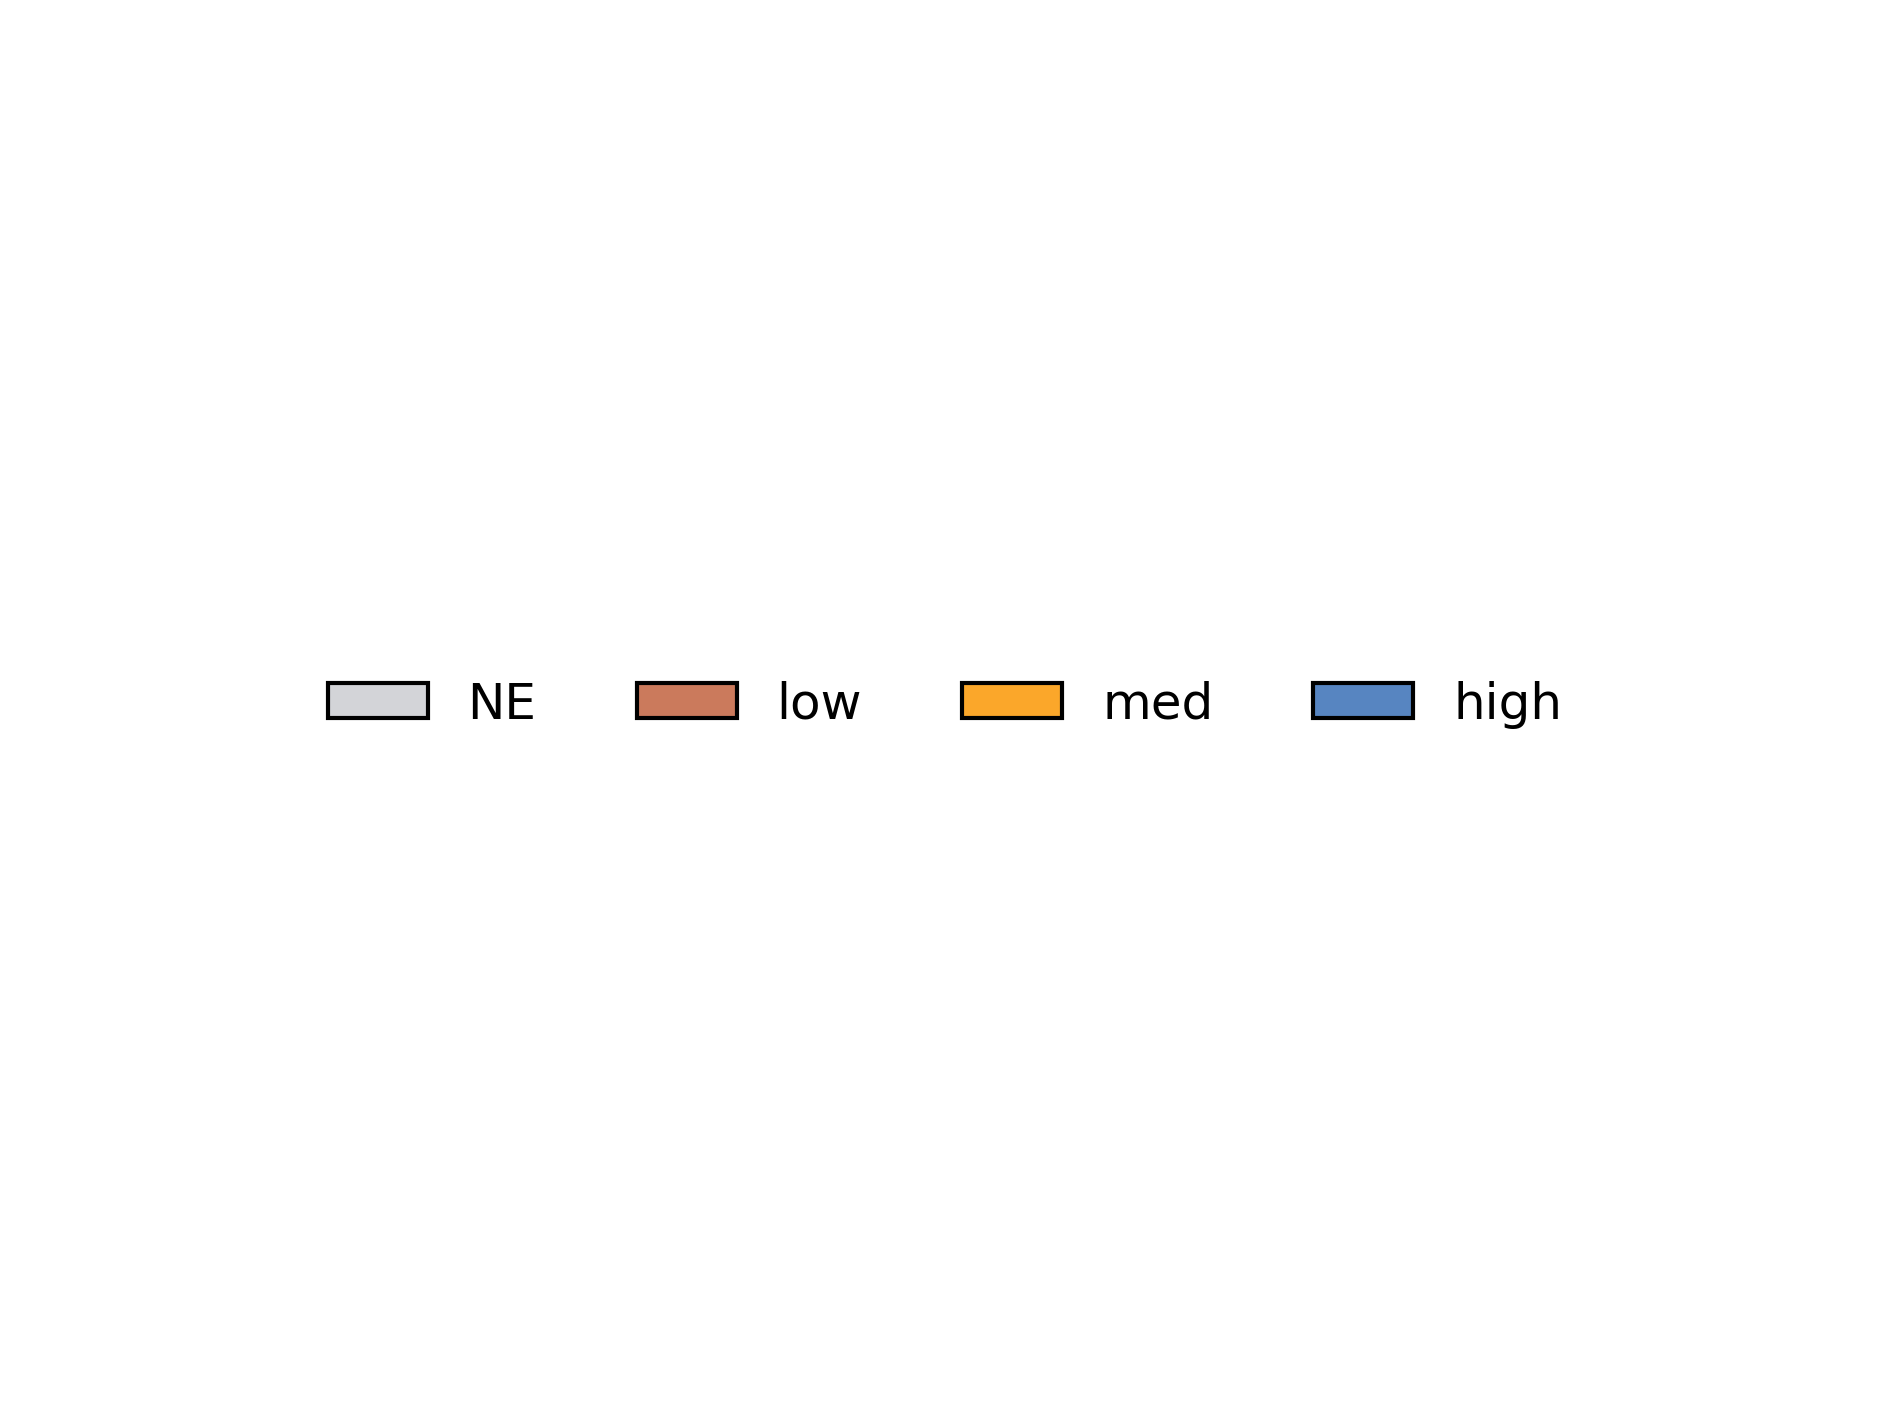

In [137]:
tmp = mdf.copy()

tmp = tmp[~tmp['is_tf']]

tmp = tmp.set_index('gene_name')
tmp = tmp[['expr_bin_Control', 'expr_bin_mmMYOD1']]

mask = tmp.ne("NE").any(axis=1)
tmp = tmp[mask]
print(f"{tmp.shape=}")
print(tmp.head(10).to_string())

stages = tmp.columns.tolist()
labels = ['NE', 'low', 'med', 'high']
label_indices = {label: i for i, label in enumerate(labels)}
colors = {
    "NE" : '#D3D4D8',
    "low": '#CB7A5C',
    "med": '#FBA72A',
    "high": '#5785C1',
}

def hex_to_rgba(hex_color, alpha=0.4):
    from matplotlib.colors import to_rgba
    rgba = to_rgba(hex_color, alpha)
    return f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f})"

# Desired vertical sort order (top to bottom)
label_order = ['high', 'med', 'low', 'NE']

# Build nodes in consistent stage-wise order
nodes = []
node_lookup = {}
idx = 0
for stage in stages:
    for label in label_order:
        node_name = f"{stage}_{label}"
        nodes.append(node_name)
        node_lookup[node_name] = idx
        idx += 1

source = []
target = []
value = []
link_color = []

for i in range(len(stages) - 1):
    src_stage = stages[i]
    tgt_stage = stages[i + 1]
    
    transitions = tmp[[src_stage, tgt_stage]].values.tolist()
    counts = Counter(tuple(pair) for pair in transitions)
    
    for (src_val, tgt_val), count in counts.items():
        if src_val in labels and tgt_val in labels:
            src_idx = node_lookup[f"{src_stage}_{src_val}"]
            tgt_idx = node_lookup[f"{tgt_stage}_{tgt_val}"]
            source.append(src_idx)
            target.append(tgt_idx)
            value.append(count)
            link_color.append(hex_to_rgba(colors[src_val], alpha=0.5)),

# Sankey plot
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=30,
        line=dict(color="black", width=1.5),
        # label=[node.split('_')[0] for node in nodes],  # Strip stage
        color=[colors[node.rsplit('_', 1)[1]] for node in nodes]
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_color,
    ))])

fig.update_layout(
    font_size=20,
    height=700,
    width=400,
)
fig.show()

# Create legend handles
legend_elements = [Patch(facecolor=color, edgecolor='k', label=label)
                   for label, color in colors.items()]

# Create figure with only the legend
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots()
ax.axis('off')
legend = ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    ncols=4,
    fontsize=12,
)
plt.tight_layout()
plt.show()

In [134]:
tmp[tmp['expr_bin_mmMYOD1'] == 'NE']

,expr_bin_Control,expr_bin_mmMYOD1
gene_name,,
CARM1,low,NE
CD99L2,low,NE
CENPA,med,NE
IGFBP2,low,NE
MAPK3,low,NE
SDC3,low,NE
SIRT2,low,NE
SREBF1,low,NE
TGFBR1,low,NE


In [105]:
# order your bins
order = ["not expressed", "low", "med", "high"]
rank = {k: i for i, k in enumerate(order)}

# map bins to ranks
c0 = mdf["expr_bin_Control"].map(rank)
c1 = mdf["expr_bin_mmMYOD1"].map(rank)

# how many increased (moved up at least one bin)
n_up = (c1 > c0).sum()
print(f"Genes that increased bin in mmMYOD1 vs Control: {n_up}")

# optional: breakdown of transitions (from -> to)
transitions = pd.crosstab(mdf["expr_bin_Control"], mdf["expr_bin_mmMYOD1"])
display(transitions)

# optional: list genes that increased
increased_genes = mdf.loc[c1 > c0, "gene_name"].tolist()
print(len(increased_genes))

Genes that increased bin in mmMYOD1 vs Control: 94


expr_bin_mmMYOD1,high,low,med,not expressed
expr_bin_Control,,,,
high,66,0,15,0
low,3,37,32,8
med,30,8,40,1
not expressed,4,18,7,0


94


In [20]:
### adjust MYOD1 subgraph edges based on expression bins --> then compare those networks

bin_score = {
    'not expressed': 0,
    'low': 1,
    'med': 2,
    'high': 3,
}

def make_weighted_graph(G_base, mdf, bin_col, combine="min"):
    # node -> score
    node_score = dict(zip(mdf["gene_name"], mdf[bin_col].map(bin_score)))

    Gw = G_base.copy()
    for u, v in Gw.edges():
        su = node_score.get(u, 0)
        sv = node_score.get(v, 0)

        if combine == "min":
            w = min(su, sv)
        elif combine == "product":
            w = su * sv
        elif combine == "geom":
            w = (su * sv) ** 0.5
        else:
            raise ValueError("combine must be 'min', 'product', or 'geom'")

        Gw[u][v]["weight"] = float(w)
    return Gw


BGM_wM = make_weighted_graph(BGM, mdf, bin_col='expr_bin_mmMYOD1', combine='product')
BGM_wC = make_weighted_graph(BGM, mdf, bin_col='expr_bin_Control', combine='product')

In [21]:
def edge_weight_series(G):
    return [d.get("weight", 0.0) for _, _, d in G.edges(data=True)]

ctrl_sum = sum(edge_weight_series(BGM_wC))
treat_sum = sum(edge_weight_series(BGM_wM))
print("Sum edge weight (Control):", ctrl_sum)
print("Sum edge weight (mmMYOD1):", treat_sum)
print("Delta:", treat_sum - ctrl_sum)

Sum edge weight (Control): 34158.0
Sum edge weight (mmMYOD1): 44680.0
Delta: 10522.0


In [139]:
# def minmax_from_control(mdf, expr_col, ref_col="Control", is_tf_col="is_tf"):
#     a = {}
#     for tf_flag in [True, False]:
#         mask = mdf[is_tf_col].eq(tf_flag)
#         ref = mdf.loc[mask, ref_col].astype(float)
#         lo, hi = ref.min(), ref.max()
#         # avoid divide-by-zero
#         denom = (hi - lo) if hi > lo else 1.0
#         a[tf_flag] = (lo, denom)

#     scaled = np.zeros(len(mdf), dtype=float)
#     for tf_flag in [True, False]:
#         mask = mdf[is_tf_col].eq(tf_flag).to_numpy()
#         lo, denom = a[tf_flag]
#         x = mdf.loc[mask, expr_col].astype(float).to_numpy()
#         s = (x - lo) / denom
#         scaled[mask] = np.clip(s, 0, 1)
#     return scaled

# mdf["a_Control"]  = minmax_from_control(mdf, "Control")
# mdf["a_mmMYOD1"]  = minmax_from_control(mdf, "mmMYOD1")

# def robust_minmax_from_control(mdf, expr_col, ref_col="Control", is_tf_col="is_tf",
#                                q_low=0.01, q_high=0.99):
#     scaled = np.zeros(len(mdf), dtype=float)

#     for tf_flag in [True, False]:
#         mask = mdf[is_tf_col].eq(tf_flag).to_numpy()
#         ref = mdf.loc[mask, ref_col].astype(float)

#         lo = ref.quantile(q_low)
#         hi = ref.quantile(q_high)
#         print(lo, hi)
#         denom = (hi - lo) if hi > lo else 1.0

#         x = mdf.loc[mask, expr_col].astype(float).to_numpy()
#         s = (x - lo) / denom
#         scaled[mask] = np.clip(s, 0, 1)

#     return scaled

# mdf["a_Control"] = robust_minmax_from_control(mdf, "Control")
# mdf["a_mmMYOD1"] = robust_minmax_from_control(mdf, "mmMYOD1")

def robust_minmax_from_control_nonzero(mdf, expr_col, ref_col="Control", is_tf_col="is_tf",
                                       q_low=0.01, q_high=0.99, eps=1e-12):
    scaled = np.zeros(len(mdf), dtype=float)

    for tf_flag in [True, False]:
        mask = mdf[is_tf_col].eq(tf_flag).to_numpy()
        ref = mdf.loc[mask, ref_col].astype(float)

        ref_nz = ref[ref > 0]
        if len(ref_nz) == 0:
            # everything is zero in control for this group
            scaled[mask] = 0.0
            continue

        lo = ref_nz.quantile(q_low)
        hi = ref_nz.quantile(q_high)
        print(lo, hi)
        denom = (hi - lo) if hi > lo else 1.0

        x = mdf.loc[mask, expr_col].astype(float).to_numpy()

        s = (x - lo) / denom
        s[x <= 0] = 0.0                 # keep true zeros at 0
        scaled[mask] = np.clip(s, 0, 1)

    return scaled

mdf["a_Control"] = robust_minmax_from_control_nonzero(mdf, "Control")
mdf["a_mmMYOD1"] = robust_minmax_from_control_nonzero(mdf, "mmMYOD1")

mdf.head()

0.07488336650924293 1.7497369632609696
0.08326533476768716 3.5713572167553607
0.07488336650924293 1.7497369632609696
0.08326533476768716 3.5713572167553607


,gene_name,Control,mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,is_tf,expr_bin_Control,expr_bin_mmMYOD1,a_Control,a_mmMYOD1
0,ACP1,0.635502,0.708555,0.693422,0.627494,False,med,high,0.158321,0.179264
1,ACTB,3.573045,2.915236,0.998986,0.934368,False,high,high,1.000000,0.811897
2,ACTC1,0.000000,0.355265,0.045349,0.142794,False,NE,med,0.000000,0.077980
3,ACTN2,0.000000,0.150222,0.000145,0.118404,False,NE,low,0.000000,0.019196
4,ACVR2A,0.000000,0.162729,0.080556,0.164967,False,NE,low,0.000000,0.022781


In [23]:
mdf[mdf['a_mmMYOD1'] == 1]

,gene_name,Control,mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,is_tf,expr_bin_Control,expr_bin_mmMYOD1,a_Control,a_mmMYOD1
160,MYOD1,0.000000,1.803419,0.000000,0.936585,True,not expressed,high,0.0,1.0
238,STAT1,2.340459,2.516557,0.998696,0.976940,True,high,high,1.0,1.0


In [140]:
mdf[['a_Control', 'a_mmMYOD1']].describe()

,a_Control,a_mmMYOD1
count,269.000000,269.000000
mean,0.160002,0.191084
std,0.210707,0.209094
min,0.000000,0.000000
25%,0.021572,0.047969
50%,0.080561,0.123412
75%,0.198712,0.252317
max,1.000000,1.000000


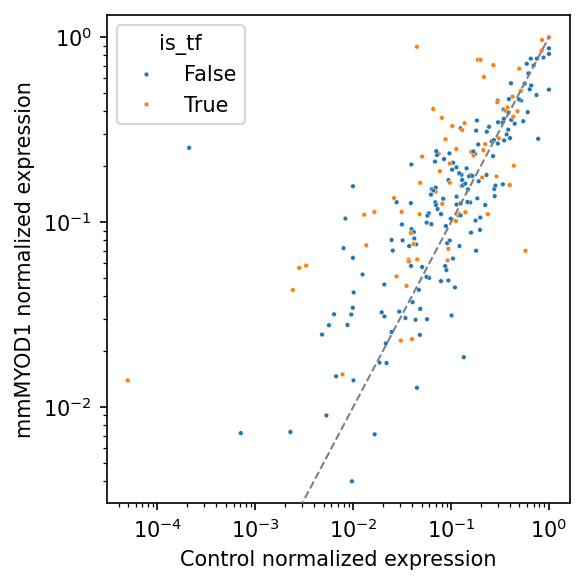

In [154]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=150)

sns.scatterplot(
    data=mdf,
    x='a_Control',
    y='a_mmMYOD1',
    s=5,
    hue='is_tf',
)

ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, zorder=10)
ax.set_xscale('log')
ax.set_yscale('log')

plt.xlabel("Control normalized expression")
plt.ylabel("mmMYOD1 normalized expression")

plt.tight_layout()
plt.show()

In [25]:
# make node -> activity dicts
a_ctrl = dict(zip(mdf["gene_name"], mdf["a_Control"]))
a_mmy  = dict(zip(mdf["gene_name"], mdf["a_mmMYOD1"]))

def add_edge_weights_from_node_activity(G, a, weight_attr="weight", combine="product"):
    Gw = G.copy()
    for u, v in Gw.edges():
        au = a.get(u, 0.0)
        av = a.get(v, 0.0)
        if combine == "product":
            w = au * av
        elif combine == "min":
            w = min(au, av)
        elif combine == "mean":
            w = 0.5 * (au + av)
        else:
            raise ValueError("combine must be 'product', 'min', or 'mean'")
        Gw[u][v][weight_attr] = float(w)
    return Gw

# weighted graphs per condition
sub_GM_control = add_edge_weights_from_node_activity(BGM, a_ctrl, weight_attr="weight", combine="product")
sub_GM_mmMYOD1 = add_edge_weights_from_node_activity(BGM, a_mmy,  weight_attr="weight", combine="product")


ctrl_sum = sum(edge_weight_series(sub_GM_control))
treat_sum = sum(edge_weight_series(sub_GM_mmMYOD1))
print("Sum edge weight (Control):", ctrl_sum)
print("Sum edge weight (mmMYOD1):", treat_sum)
print("Delta:", treat_sum - ctrl_sum)

Sum edge weight (Control): 310.003658535466
Sum edge weight (mmMYOD1): 484.0693148980231
Delta: 174.0656563625571


In [27]:
print(f'Is connected? {nx.is_connected(sub_GM_control)}')
print(f'N connected components: {nx.number_connected_components(sub_GM_control)}')
print(f'Largest connected components has {len(max(nx.connected_components(sub_GM_control), key=len))} nodes')

print(f'\nIs connected? {nx.is_connected(sub_GM_mmMYOD1)}')
print(f'N connected components: {nx.number_connected_components(sub_GM_mmMYOD1)}')
print(f'Largest connected components has {len(max(nx.connected_components(sub_GM_mmMYOD1), key=len))} nodes')

Is connected? True
N connected components: 1
Largest connected components has 269 nodes

Is connected? True
N connected components: 1
Largest connected components has 269 nodes


In [62]:
def n_active_edges(G, weight="weight"):
    return sum(1 for _,_,d in G.edges(data=True) if d.get(weight, 0.0) > 0)

print("Active edges Control:", n_active_edges(sub_GM_control))
print("Active edges mmMYOD1:", n_active_edges(sub_GM_mmMYOD1))

# density of active edges
Md = (2 * n_active_edges(sub_GM_mmMYOD1)) / (sub_GM_mmMYOD1.number_of_nodes() * (sub_GM_mmMYOD1.number_of_nodes() - 1))
Cd = (2 * n_active_edges(sub_GM_control)) / (sub_GM_control.number_of_nodes() * (sub_GM_control.number_of_nodes() - 1))

print(f"Active graph density Control: {Cd:.4f}")
print(f"Active graph density mmMYOD1: {Md:.4f}")

Active edges Control: 7760
Active edges mmMYOD1: 9210
Active graph density Control: 0.2153
Active graph density mmMYOD1: 0.2555


In [ ]:
# shannon 

In [63]:
def active_eigenvector_centrality_df(G, weight="weight", zero_tol=0.0, label=None):
    """
    Computes eigenvector centrality on the largest connected component of the
    subgraph induced by edges with weight > zero_tol. Nodes not in that component
    (or with no active edges) get 0 centrality.

    Returns a DataFrame with columns:
      - gene_name
      - eigencent_{label}
      - strength_{label}   (weighted degree)
      - degree_{label}     (unweighted degree in the original G)
    """
    # Build active-edge subgraph (keep all nodes for alignment)
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from((u, v, d) for u, v, d in G.edges(data=True) if d.get(weight, 0.0) > zero_tol)

    # defaults
    ec = {n: 0.0 for n in G.nodes()}

    if H.number_of_edges() > 0:
        lcc_nodes = max(nx.connected_components(H), key=len)
        print(f"{label} largest connected component: {len(lcc_nodes)} nodes")
        H_lcc = H.subgraph(lcc_nodes).copy()
        ec_lcc = nx.eigenvector_centrality(H_lcc, weight=weight, max_iter=10_000)
        ec.update(ec_lcc)

    strength = dict(G.degree(weight=weight))  # weighted degree in original weighted graph
    degree = dict(G.degree())                # unweighted degree in original graph

    suffix = "" if label is None else f"_{label}"
    return pd.DataFrame({
        "gene_name": list(G.nodes()),
        f"eigencent{suffix}": [ec[n] for n in G.nodes()],
        f"strength{suffix}": [strength.get(n, 0.0) for n in G.nodes()],
        f"degree{suffix}":   [degree.get(n, 0) for n in G.nodes()],
    })

# Example usage
df_ctrl = active_eigenvector_centrality_df(sub_GM_control, weight="weight", zero_tol=0.0, label="Control")
df_mmy  = active_eigenvector_centrality_df(sub_GM_mmMYOD1,  weight="weight", zero_tol=0.0, label="mmMYOD1")

# Merge into one table and compute deltas
centrality_df = df_ctrl.merge(df_mmy, on="gene_name", how="outer")

centrality_df["delta_eigencent"] = centrality_df["eigencent_mmMYOD1"] - centrality_df["eigencent_Control"]
centrality_df["delta_strength"]  = centrality_df["strength_mmMYOD1"]  - centrality_df["strength_Control"]

centrality_df.head()

Control largest connected component: 237 nodes
mmMYOD1 largest connected component: 260 nodes


,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,delta_eigencent,delta_strength
0,ACP1,0.010913,0.494604,11,0.011812,0.713655,11,0.000899,0.219051
1,ACTB,0.353890,33.687181,198,0.258004,33.008099,198,-0.095885,-0.679082
2,ACTC1,0.000000,0.000000,39,0.007771,0.725462,39,0.007771,0.725462
3,ACTN2,0.000000,0.000000,31,0.001592,0.145622,31,0.001592,0.145622
4,ACVR2A,0.000000,0.000000,26,0.001672,0.126651,26,0.001672,0.126651


In [62]:
centrality_df.sort_values(by='delta_eigencent', ascending=False).head(10)

,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,delta_eigencent,delta_strength
160,MYOD1,0.000000,0.000000,268,0.325361,50.401603,268,0.325361,50.401603
12,ATF3,0.008895,0.612199,83,0.190744,17.080630,83,0.181849,16.468431
204,RUNX1,0.048737,3.950702,122,0.177766,19.095406,122,0.129029,15.144704
123,JUN,0.089433,7.660187,172,0.212294,25.175140,172,0.122862,17.514953
67,EGR1,0.060258,4.538490,128,0.162180,16.847036,128,0.101922,12.308546
75,ESR1,0.000000,0.000000,171,0.100987,11.744173,171,0.100987,11.744173
173,NFKB1,0.019768,1.535540,149,0.113229,12.134343,149,0.093462,10.598802
156,MYC,0.030218,2.920638,211,0.123119,15.959974,211,0.092901,13.039337
171,NFAT5,0.025771,1.506450,42,0.109374,8.384483,42,0.083603,6.878033
88,FOXO3,0.025729,2.145393,133,0.087478,9.136322,133,0.061749,6.990929


In [65]:
centrality_df.sort_values(by='delta_strength', ascending=False).head(10)

,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,delta_eigencent,delta_strength
160,MYOD1,0.000000,0.000000,268,0.325361,50.401603,268,0.325361,50.401603
123,JUN,0.089433,7.660187,172,0.212294,25.175140,172,0.122862,17.514953
12,ATF3,0.008895,0.612199,83,0.190744,17.080630,83,0.181849,16.468431
204,RUNX1,0.048737,3.950702,122,0.177766,19.095406,122,0.129029,15.144704
156,MYC,0.030218,2.920638,211,0.123119,15.959974,211,0.092901,13.039337
67,EGR1,0.060258,4.538490,128,0.162180,16.847036,128,0.101922,12.308546
75,ESR1,0.000000,0.000000,171,0.100987,11.744173,171,0.100987,11.744173
173,NFKB1,0.019768,1.535540,149,0.113229,12.134343,149,0.093462,10.598802
100,H3-3B,0.168588,14.537470,167,0.196678,22.689832,167,0.028091,8.152362
32,CCND1,0.101114,8.486199,168,0.134741,15.605586,168,0.033627,7.119387


In [68]:
display(centrality_df.sort_values(by='eigencent_Control', ascending=False).head(10))
display(centrality_df.sort_values(by='eigencent_mmMYOD1', ascending=False).head(10))

,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,delta_eigencent,delta_strength
1,ACTB,0.353890,33.687181,198,0.258004,33.008099,198,-0.095885,-0.679082
51,COL1A1,0.282606,20.442118,101,0.121752,12.320742,101,-0.160854,-8.121376
92,GAPDH,0.278977,26.474345,207,0.248233,32.485968,207,-0.030744,6.011622
106,HIF1A,0.266448,22.541814,157,0.243946,28.066784,157,-0.022502,5.524970
238,STAT1,0.258590,19.629254,121,0.250243,25.791979,121,-0.008347,6.162726
84,FN1,0.223910,17.842684,140,0.158656,17.677641,140,-0.065254,-0.165044
108,HSP90AA1,0.205307,17.748272,141,0.191056,22.122013,141,-0.014251,4.373740
122,ITGB1,0.198910,12.851606,81,0.100832,9.576431,81,-0.098078,-3.275175
27,CAV1,0.184329,13.177460,97,0.140275,14.905831,97,-0.044054,1.728371
85,FOS,0.170249,15.308476,162,0.020786,2.406657,162,-0.149463,-12.901819


,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,delta_eigencent,delta_strength
160,MYOD1,0.000000,0.000000,268,0.325361,50.401603,268,0.325361,50.401603
1,ACTB,0.353890,33.687181,198,0.258004,33.008099,198,-0.095885,-0.679082
238,STAT1,0.258590,19.629254,121,0.250243,25.791979,121,-0.008347,6.162726
92,GAPDH,0.278977,26.474345,207,0.248233,32.485968,207,-0.030744,6.011622
106,HIF1A,0.266448,22.541814,157,0.243946,28.066784,157,-0.022502,5.524970
123,JUN,0.089433,7.660187,172,0.212294,25.175140,172,0.122862,17.514953
100,H3-3B,0.168588,14.537470,167,0.196678,22.689832,167,0.028091,8.152362
108,HSP90AA1,0.205307,17.748272,141,0.191056,22.122013,141,-0.014251,4.373740
12,ATF3,0.008895,0.612199,83,0.190744,17.080630,83,0.181849,16.468431
204,RUNX1,0.048737,3.950702,122,0.177766,19.095406,122,0.129029,15.144704


In [69]:
display(centrality_df.sort_values(by='strength_Control', ascending=False).head(10))
display(centrality_df.sort_values(by='strength_mmMYOD1', ascending=False).head(10))

,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,delta_eigencent,delta_strength
1,ACTB,0.353890,33.687181,198,0.258004,33.008099,198,-0.095885,-0.679082
92,GAPDH,0.278977,26.474345,207,0.248233,32.485968,207,-0.030744,6.011622
106,HIF1A,0.266448,22.541814,157,0.243946,28.066784,157,-0.022502,5.524970
51,COL1A1,0.282606,20.442118,101,0.121752,12.320742,101,-0.160854,-8.121376
238,STAT1,0.258590,19.629254,121,0.250243,25.791979,121,-0.008347,6.162726
84,FN1,0.223910,17.842684,140,0.158656,17.677641,140,-0.065254,-0.165044
108,HSP90AA1,0.205307,17.748272,141,0.191056,22.122013,141,-0.014251,4.373740
85,FOS,0.170249,15.308476,162,0.020786,2.406657,162,-0.149463,-12.901819
100,H3-3B,0.168588,14.537470,167,0.196678,22.689832,167,0.028091,8.152362
27,CAV1,0.184329,13.177460,97,0.140275,14.905831,97,-0.044054,1.728371


,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,delta_eigencent,delta_strength
160,MYOD1,0.000000,0.000000,268,0.325361,50.401603,268,0.325361,50.401603
1,ACTB,0.353890,33.687181,198,0.258004,33.008099,198,-0.095885,-0.679082
92,GAPDH,0.278977,26.474345,207,0.248233,32.485968,207,-0.030744,6.011622
106,HIF1A,0.266448,22.541814,157,0.243946,28.066784,157,-0.022502,5.524970
238,STAT1,0.258590,19.629254,121,0.250243,25.791979,121,-0.008347,6.162726
123,JUN,0.089433,7.660187,172,0.212294,25.175140,172,0.122862,17.514953
100,H3-3B,0.168588,14.537470,167,0.196678,22.689832,167,0.028091,8.152362
108,HSP90AA1,0.205307,17.748272,141,0.191056,22.122013,141,-0.014251,4.373740
204,RUNX1,0.048737,3.950702,122,0.177766,19.095406,122,0.129029,15.144704
84,FN1,0.223910,17.842684,140,0.158656,17.677641,140,-0.065254,-0.165044


In [81]:
mtmp_cols = [col for col in centrality_df.columns if 'mmMYOD1' in col]
ctmp_cols = [col for col in centrality_df.columns if 'Control' in col]

ctmp = centrality_df.drop(columns=mtmp_cols)
print(ctmp.shape)

mtmp = centrality_df.drop(columns=ctmp_cols)
mtmp = mtmp.sort_values(by='eigencent_mmMYOD1', ascending=False)
print(mtmp.shape)
mtmp.tail(10)

(269, 6)
(269, 6)


,gene_name,eigencent_mmMYOD1,strength_mmMYOD1,degree_mmMYOD1,delta_eigencent,delta_strength
24,CAPN3,0.000136,0.012031,15,0.000136,0.012031
25,CARM1,0.000000,0.000000,75,-0.004997,-0.403575
139,MAPK3,0.000000,0.000000,137,-0.004043,-0.310738
254,TGFBR1,0.000000,0.000000,84,-0.006578,-0.418498
234,SREBF1,0.000000,0.000000,77,-0.003001,-0.201556
37,CD99L2,0.000000,0.000000,16,-0.000185,-0.024851
48,CENPA,0.000000,0.000000,46,-0.012155,-0.949963
117,IGFBP2,0.000000,0.000000,28,-0.004024,-0.195301
207,SDC3,0.000000,0.000000,9,-0.001115,-0.075894
214,SIRT2,0.000000,0.000000,72,0.000000,0.000000


In [82]:
# mtmp['degree_mmMYOD1'].mean() # same as original subgraph

# how many 0 strength nodes
print(f"mmMYOD1:\nN genes with weighted degree = 0: {len(mtmp[mtmp['strength_mmMYOD1'] == 0.0])}")

print(f"Mean degree strength (with 0s): {mtmp['strength_mmMYOD1'].mean():.3f}")
print(f"Mean degree strength (no 0s): {mtmp['strength_mmMYOD1'].replace(0, np.nan).mean():.3f}")


print(f"\nControl:\nN genes with weighted degree = 0: {len(ctmp[ctmp['strength_Control'] == 0.0])}")
print(f"Mean degree strength (with 0s): {ctmp['strength_Control'].mean():.3f}")
print(f"Mean degree strength (no 0s): {ctmp['strength_Control'].replace(0, np.nan).mean():.3f}")


mmMYOD1:
N genes with weighted degree = 0: 9
Mean degree strength (with 0s): 3.599
Mean degree strength (no 0s): 3.724

Control:
N genes with weighted degree = 0: 32
Mean degree strength (with 0s): 2.305
Mean degree strength (no 0s): 2.616


In [86]:
print(f"Σ weighted degrees mmMYOD1: {mtmp['strength_mmMYOD1'].sum():.3f}")
print(f"Σ weighted degrees Control: {ctmp['strength_Control'].sum():.3f}")

Σ weighted degrees mmMYOD1: 968.139
Σ weighted degrees Control: 620.007


In [43]:
## Entropy

def shannon_entropy_edges(G, weight='weight', base=2, ignore_zeros=True, eps=1e-12, cond='Control'):
    
    w = np.fromiter((d.get(weight, 0.0) for _, _, d in G.edges(data=True)), dtype=float)
    
    if w.size == 0:
        return 0.0
    
    if ignore_zeros:
        w = w[w > eps]
        if w.size == 0:
            return 0.0
        
    # prob distribution
    weights_sum = w.sum()
    if weights_sum <= 0:
        return 0.0
    
    p = w / weights_sum
    
    H = float(-(p * (np.log(p) / np.log(base))).sum())
    
    # normalize to max
    n_edges = p.size
    print(f'N edges included for {cond}: {n_edges}')
    max_H = float(np.log(n_edges) / np.log(base)) if n_edges > 1 else 0.0
    H_norm = (H / max_H) if max_H > 0 else 0.0
    
    return H, max_H, H_norm, p



H_ctrl, Hmax_ctrl, Hnorm_ctrl, p_ctrl = shannon_entropy_edges(sub_GM_control, cond='Control')
H_mmy, Hmax_mmy, Hnorm_mmy, p_mmy = shannon_entropy_edges(sub_GM_mmMYOD1, cond='mmMYOD1')

print(f'\nControl:\n H = {H_ctrl:.3f}\n H_norm = {Hnorm_ctrl:.3f}\n H_max = {Hmax_ctrl:.3f}')
print(f'\nmmMYOD1:\n H = {H_mmy:.3f}\n H_norm = {Hnorm_mmy:.3f}\n H_max = {Hmax_mmy:.3f}')

N edges included for Control: 7760
N edges included for mmMYOD1: 9210

Control:
 H = 11.294
 H_norm = 0.874
 H_max = 12.922

mmMYOD1:
 H = 11.873
 H_norm = 0.902
 H_max = 13.169


In [89]:
# entropy on degree ?
# def structural_entropy_strength_distribution(G, weight="weight", bins=30, base=2, normalize=True, eps=1e-12):
#     strength = np.fromiter((d for _, d in G.degree(weight=weight)), dtype=float)

#     # histogram -> p(bin)
#     strength = strength[strength > -np.inf]  # no-op, just explicit
#     hist, edges = np.histogram(strength, bins=bins)
#     p = hist.astype(float)
#     p = p[p > 0]
#     p = p / p.sum()

#     Hs = float(-(p * (np.log(p) / np.log(base))).sum())

#     if not normalize:
#         return Hs

#     K = len(p)
#     Hmax = float(np.log(K) / np.log(base)) if K > 1 else 0.0
#     Hnorm = (Hs / Hmax) if Hmax > 0 else 0.0
#     return Hs, Hmax, Hnorm

def structural_entropy_active_degree(G, weight="weight", thresh=0.0, base=2, normalize=True):
    """
    Structural entropy from the degree distribution of the active (thresholded) graph.

    Active graph: keep edges with edge_attr[weight] > thresh.
    Degrees computed on that active graph, including isolated nodes (degree 0).

    Returns
    -------
    If normalize:
        (H, H_max, H_norm, p_of_d_dict)
    else:
        (H, p_of_d_dict)
    """
    # build thresholded (active) graph while retaining all nodes
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from((u, v) for u, v, d in G.edges(data=True) if d.get(weight, 0.0) > thresh)

    deg = np.fromiter((d for _, d in H.degree()), dtype=int)

    # p(d) over degree values
    dvals, counts = np.unique(deg, return_counts=True)
    p = counts / counts.sum()

    Hent = float(-(p * (np.log(p) / np.log(base))).sum())
    p_of_d = {int(d): float(pi) for d, pi in zip(dvals, p)}

    if not normalize:
        return Hent, p_of_d

    K = len(p)  # number of distinct degree values observed
    H_max = float(np.log(K) / np.log(base)) if K > 1 else 0.0
    H_norm = (Hent / H_max) if H_max > 0 else 0.0
    return Hent, H_max, H_norm, p_of_d


H_ctrl, Hmax_ctrl, Hnorm_ctrl, pc = structural_entropy_active_degree(sub_GM_control, thresh=0.0)
H_mmy, Hmax_mmy, Hnorm_mmy, pm = structural_entropy_active_degree(sub_GM_mmMYOD1, thresh=0.0)

print(f'Control:\n H = {H_ctrl:.3f}\n H_norm = {Hnorm_ctrl:.3f}\n H_max = {Hmax_ctrl:.3f}')
print(f'\nmmMYOD1:\n H = {H_mmy:.3f}\n H_norm = {Hnorm_mmy:.3f}\n H_max = {Hmax_mmy:.3f}')

Control:
 H = 6.418
 H_norm = 0.928
 H_max = 6.919

mmMYOD1:
 H = 6.796
 H_norm = 0.960
 H_max = 7.077


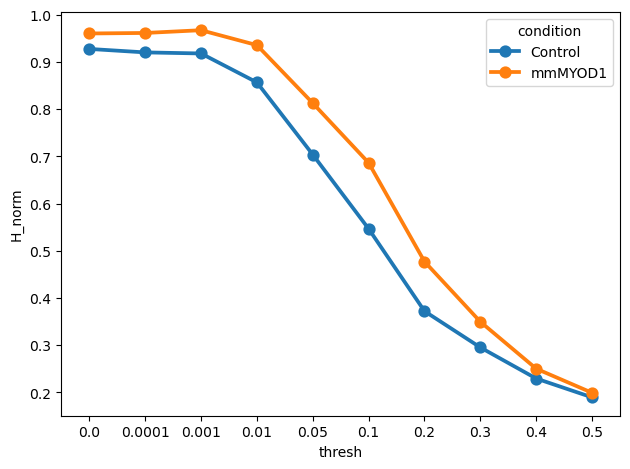

In [97]:
thresholds = [0, 1e-4, 1e-3, 1e-2, 5e-2, 0.1, 0.2, 0.3, 0.4, 0.5]
rows = []
for t in thresholds:
    Hc, _, Hcn, _ = structural_entropy_active_degree(sub_GM_control, thresh=t)
    Hm, _, Hmn, _ = structural_entropy_active_degree(sub_GM_mmMYOD1,  thresh=t)
    rows.append((t, Hcn, Hmn))

ent_df = pd.DataFrame(rows, columns=["thresh", "Control", "mmMYOD1"])

ent_df = ent_df.melt(id_vars=['thresh'], var_name='condition', value_name='H_norm') 
ent_df

sns.pointplot(
    data=ent_df,
    x='thresh',
    y='H_norm',
    hue='condition',
)

plt.tight_layout()
plt.show()

In [ ]:
def structural_entropy_strength_distribution(
    G,
    weight="weight",
    bins=30,
    bin_edges=None,
    base=2,
    normalize=True,
    ignore_zeros=True,
    eps=1e-12,
):
    """
    Structural entropy from the distribution of node strengths (weighted degrees).

    strength_i = sum_j w_ij  (NetworkX degree(weight=...))

    Because strengths are continuous, we estimate p via a histogram.
    For fair comparisons between conditions, pass the SAME bin_edges to both.

    Parameters
    ----------
    bins : int
        Number of bins if bin_edges is None.
    bin_edges : array-like or None
        Explicit bin edges to use (recommended for comparing conditions).
    ignore_zeros : bool
        If True, drops nodes with strength <= eps (isolates) before histogramming.

    Returns
    -------
    If normalize:
        (H, H_max, H_norm, hist, used_bin_edges)
    else:
        (H, hist, used_bin_edges)
    """
    strength = np.fromiter((d for _, d in G.degree(weight=weight)), dtype=float)

    if ignore_zeros:
        strength = strength[strength > eps]
        if strength.size == 0:
            if normalize:
                return 0.0, 0.0, 0.0, np.array([], dtype=int), np.array([])
            return 0.0, np.array([], dtype=int), np.array([])

    if bin_edges is None:
        # handle constant-strength edge case
        smin, smax = float(strength.min()), float(strength.max())
        if smax <= smin:
            bin_edges = np.array([smin, smin + 1e-12])
        else:
            bin_edges = np.linspace(smin, smax, bins + 1)
    else:
        bin_edges = np.asarray(bin_edges, dtype=float)

    hist, used_edges = np.histogram(strength, bins=bin_edges)
    p = hist.astype(float)
    p = p[p > 0]
    p = p / p.sum()

    H = float(-(p * (np.log(p) / np.log(base))).sum())

    if not normalize:
        return H, hist, used_edges

    K = len(p)  # number of non-empty bins
    H_max = float(np.log(K) / np.log(base)) if K > 1 else 0.0
    H_norm = (H / H_max) if H_max > 0 else 0.0
    return H, H_max, H_norm, hist, used_edges

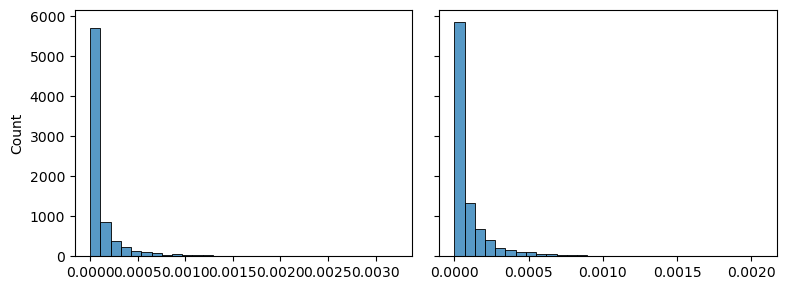

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(8,3), sharey=True)


conditions = {
    'Control': p_ctrl,
    'mmMYOD1': p_mmy,
}

bins = 30

for i, (cond, vals) in enumerate(conditions.items()):
    ax = axes[i]
    
    sns.histplot(
        vals,
        bins=bins,
        ax=ax,
    )
    
    # ax.set_xscale('log')
    
plt.tight_layout()
plt.show()

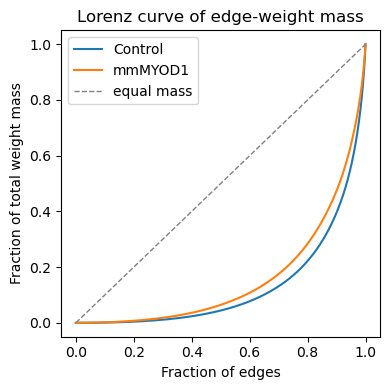

In [53]:
def lorenz_curve(p):
    p = np.asarray(p, dtype=float)
    p = np.sort(p)  # ascending
    cum_p = np.cumsum(p)
    cum_p = np.insert(cum_p, 0, 0.0)
    x = np.linspace(0, 1, len(cum_p))
    y = cum_p / cum_p[-1] if cum_p[-1] > 0 else cum_p
    return x, y

conditions = {"Control": p_ctrl, "mmMYOD1": p_mmy}

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for cond, p in conditions.items():
    x, y = lorenz_curve(p)
    ax.plot(x, y, label=cond)

ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="equal mass")
ax.set_xlabel("Fraction of edges")
ax.set_ylabel("Fraction of total weight mass")
ax.set_title("Lorenz curve of edge-weight mass")
ax.legend()
plt.tight_layout()
plt.show()

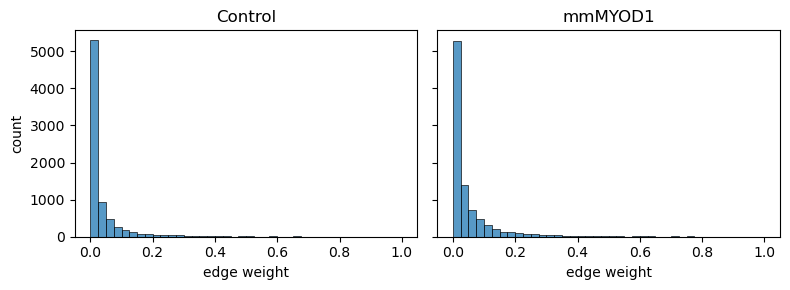

In [55]:
def get_edge_weights(G, weight="weight", ignore_zeros=True, eps=1e-12):
    w = np.fromiter((d.get(weight, 0.0) for _, _, d in G.edges(data=True)), dtype=float)
    if ignore_zeros:
        w = w[w > eps]
    return w

w_ctrl = get_edge_weights(sub_GM_control, weight="weight", ignore_zeros=True)
w_mmy  = get_edge_weights(sub_GM_mmMYOD1,  weight="weight", ignore_zeros=True)

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

bins = 40
for ax, (cond, w) in zip(axes, [("Control", w_ctrl), ("mmMYOD1", w_mmy)]):
    sns.histplot(w, bins=bins, ax=ax)
    ax.set_title(cond)
    ax.set_xlabel("edge weight")
    ax.set_ylabel("count")
    # ax.set_xscale("log")  # optional; remove if you don't want log scale

plt.tight_layout()
plt.show()

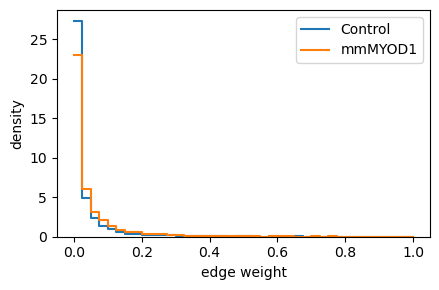

In [57]:
plt.figure(figsize=(4.5, 3))
sns.histplot(w_ctrl, bins=40, color="C0", stat="density", element="step", fill=False, label="Control")
sns.histplot(w_mmy,  bins=40, color="C1", stat="density", element="step", fill=False, label="mmMYOD1")
# plt.xscale("log")  # optional
plt.xlabel("edge weight")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

## Single-cell expression

### Score genes

In [27]:
sc.tl.score_genes(
    fdata,
    gene_list=myod_genes_robust,
    ctrl_size=len(myod_genes_robust),
    score_name='myod_nodes',
    layer='log_norm',
)

computing score 'myod_nodes'
    finished (0:00:01)


,count,mean,std,min,25%,50%,75%,max
pooled_condition,,,,,,,,
Control,6902.0,0.210810,0.031212,0.102014,0.190471,0.210704,0.231628,0.336072
mmMYOD1,2255.0,0.194746,0.041294,0.052832,0.166773,0.195198,0.222756,0.344392


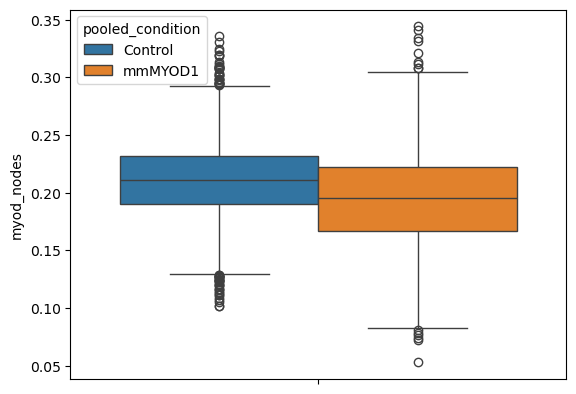

In [32]:
tmp = fdata.obs[['pooled_condition', 'myod_nodes']].copy()
tmp.head()

display(tmp.groupby('pooled_condition', observed=True)['myod_nodes'].describe())

sns.boxplot(
    data=tmp,
    y='myod_nodes',
    hue='pooled_condition',
)

plt.show()

#

# Gene-gene correlation

In [13]:
fdata

AnnData object with n_obs × n_vars = 2255 × 20928
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std

In [27]:
fdata.X = fdata.layers['log_norm'].copy()

corr_method = 'spearman'
# corr_method = 'pearson'

# MYOD1 genes
mdata = fdata[:, myod_genes].copy()
print(mdata.shape)

X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

X_df = pd.DataFrame(
    X,
    index=mdata.obs_names,
    columns=mdata.var_names,
)

RM = X_df.corr(method=corr_method)
print(RM.shape)
display(RM.head())


# PRRX1 genes
pdata = fdata[:, prrx_genes].copy()
print(pdata.shape)

X = pdata.X if isinstance(pdata.X, np.ndarray) else pdata.X.toarray()

X_df = pd.DataFrame(
    X,
    index=pdata.obs_names,
    columns=pdata.var_names,
)

RP = X_df.corr(method=corr_method)
print(RP.shape)
display(RP.head())

(2255, 411)
(411, 411)


gene_name,MYOD1,CD99,KDM1A,HOXA11,CREBBP,SOX8,IFRD1,NFIX,MLXIPL,DCN,...,CEBPD,CCNL2,TNF,TWIST2,BGLAP,EID1,SCX,PECAM1,MYMX,H3-7
gene_name,,,,,,,,,,,,,,,,,,,,,
MYOD1,1.000000,-0.447227,-0.057537,0.054825,0.060372,0.048625,0.090509,-0.022290,0.011686,-0.300169,...,0.029159,0.037871,0.087376,-0.013469,-0.010748,-0.167922,0.047809,-0.003757,0.039037,0.091860
CD99,-0.447227,1.000000,0.067576,-0.049345,-0.128083,-0.063726,-0.135293,0.098060,-0.003712,0.347997,...,-0.052534,-0.039693,-0.108181,0.020140,0.049958,0.111391,-0.022323,0.006833,-0.041800,-0.106933
KDM1A,-0.057537,0.067576,1.000000,0.038492,-0.015273,-0.010549,-0.027286,0.026292,-0.020427,0.061682,...,-0.013891,0.033737,-0.050197,0.083349,0.017915,0.034282,0.015411,0.038077,-0.009369,-0.026628
HOXA11,0.054825,-0.049345,0.038492,1.000000,0.021757,0.048628,0.018428,0.046290,0.041479,-0.018365,...,-0.017017,0.008096,-0.016454,0.021288,-0.000775,-0.008470,0.023782,-0.008763,-0.010190,-0.011876
CREBBP,0.060372,-0.128083,-0.015273,0.021757,1.000000,0.020309,0.062661,-0.036265,0.010650,-0.039830,...,0.054884,0.006707,0.038763,-0.010418,0.025205,-0.014452,-0.000713,0.011928,0.032868,0.009593


(2255, 169)
(169, 169)


gene_name,PRRX1,COPZ2,METTL13,DCN,SNAI2,VIM,CD44,CDH1,PHF23,FOXC1,...,COL5A2,POU5F1,VGLL3,EBF2,TWIST2,BGLAP,FOXD1,HOXB7,SCX,GTF2I
gene_name,,,,,,,,,,,,,,,,,,,,,
PRRX1,1.000000,0.028781,-0.031857,0.212929,0.013149,0.163227,0.166231,-0.020815,-0.009284,-0.000985,...,0.102035,-0.034424,-0.140447,-0.023028,0.107187,0.044733,0.011471,0.017030,-0.010657,0.019834
COPZ2,0.028781,1.000000,0.030825,0.167052,-0.004345,0.205668,0.075269,0.023396,-0.046140,0.009561,...,0.035545,-0.016393,0.019432,0.014704,0.030754,0.019698,0.032868,-0.027386,0.009473,0.038367
METTL13,-0.031857,0.030825,1.000000,-0.043338,0.068645,-0.058336,-0.057512,0.023594,0.009849,0.008824,...,0.009294,0.040188,0.108959,-0.002133,-0.027503,-0.005250,0.004867,0.007098,-0.025978,0.004172
DCN,0.212929,0.167052,-0.043338,1.000000,-0.056057,0.331959,0.157327,0.022803,-0.052712,0.009053,...,0.165668,-0.022517,-0.112924,-0.005939,0.160119,0.002612,-0.018532,-0.024435,-0.010581,0.068142
SNAI2,0.013149,-0.004345,0.068645,-0.056057,1.000000,-0.132361,-0.032957,0.023476,0.046834,0.037959,...,0.025806,0.019652,0.056985,-0.029247,0.071943,0.034892,0.071329,0.000257,-0.024869,0.024586


In [20]:
# MYOD1
edges = pd.DataFrame(sub_GM.edges(), columns=["gene1", "gene2"])
print(edges.shape)
edges.head()


edges["corr"] = [
    RM.loc[g1, g2] if g1 in RM.index and g2 in RM.columns else np.nan
    for g1, g2 in zip(edges["gene1"], edges["gene2"])
]

edges.head()

(18636, 2)


,gene1,gene2,corr
0,MYOD1,CD99,-0.447227
1,MYOD1,KDM1A,-0.057537
2,MYOD1,HOXA11,0.054825
3,MYOD1,CREBBP,0.060372
4,MYOD1,SOX8,0.048625


In [21]:
threshold = 0.1

edges["above_thresh"] = edges["corr"].abs() > threshold
display(edges.head())

fraction = edges["above_thresh"].mean()
print(fraction)

,gene1,gene2,corr,above_thresh
0,MYOD1,CD99,-0.447227,True
1,MYOD1,KDM1A,-0.057537,False
2,MYOD1,HOXA11,0.054825,False
3,MYOD1,CREBBP,0.060372,False
4,MYOD1,SOX8,0.048625,False


0.08628461043142305


In [22]:
edges['corr_squared'] = edges['corr'] ** 2
edges.head()

,gene1,gene2,corr,above_thresh,corr_squared
0,MYOD1,CD99,-0.447227,True,0.200012
1,MYOD1,KDM1A,-0.057537,False,0.003311
2,MYOD1,HOXA11,0.054825,False,0.003006
3,MYOD1,CREBBP,0.060372,False,0.003645
4,MYOD1,SOX8,0.048625,False,0.002364


In [23]:
edges[['corr', 'corr_squared']].describe()

,corr,corr_squared
count,18636.000000,1.863600e+04
mean,0.014480,4.752718e-03
std,0.067404,1.841744e-02
min,-0.512987,2.780868e-11
25%,-0.012954,1.197759e-04
50%,0.009267,5.840676e-04
75%,0.035461,2.268867e-03
max,0.719248,5.173177e-01


In [29]:
### soft-thresholding

corr = RM.values.copy()
np.fill_diagonal(corr, 0)

In [34]:
from scipy.stats import linregress

def scale_free_fit(adj):

    # connectivity (node degree)
    k = adj.sum(axis=1)

    # remove zeros
    k = k[k > 0]

    # histogram of connectivity
    n_bins = int(np.sqrt(len(k)))
    
    hist, bins = np.histogram(k, bins=n_bins)
    pk = hist / hist.sum()

    k_mid = (bins[:-1] + bins[1:]) / 2

    mask = (pk > 0) & (k_mid > 0)

    log_k = np.log10(k_mid[mask])
    log_pk = np.log10(pk[mask])

    if len(log_k) < 2:
        return np.nan

    r = linregress(log_k, log_pk)

    return r.rvalue**2



powers = range(1, 21)

results = []

for b in powers:

    # adj = np.abs(corr) ** b
    
    adj = (0.5 * (1 + corr)) ** b

    R2 = scale_free_fit(adj)

    mean_conn = adj.sum(axis=1).mean()

    results.append((b, R2, mean_conn))
    
    
soft_df = pd.DataFrame(
    results,
    columns=["power", "scale_free_R2", "mean_connectivity"]
)

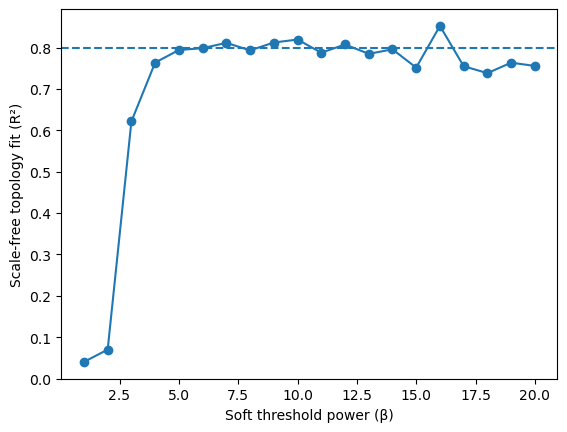

In [35]:
plt.figure()

plt.plot(soft_df.power, soft_df.scale_free_R2, marker='o')
plt.axhline(0.8, linestyle="--")

plt.xlabel("Soft threshold power (β)")
plt.ylabel("Scale-free topology fit (R²)")

plt.show()

In [37]:
soft_df.head(10)

,power,scale_free_R2,mean_connectivity
0,1,0.040333,207.387289
1,2,0.070163,104.896508
2,3,0.621558,53.188651
3,4,0.763700,27.041891
4,5,0.794045,13.789300
5,6,0.798579,7.055329
6,7,0.811419,3.624230
7,8,0.793219,1.870611
8,9,0.812204,0.971150
9,10,0.819358,0.507861


In [38]:
# MYOD1
edges = pd.DataFrame(sub_GM.edges(), columns=["gene1", "gene2"])
print(edges.shape)
edges.head()


edges["corr"] = [
    RM.loc[g1, g2] if g1 in RM.index and g2 in RM.columns else np.nan
    for g1, g2 in zip(edges["gene1"], edges["gene2"])
]

edges.head()

(18636, 2)


,gene1,gene2,corr
0,MYOD1,CD99,-0.447227
1,MYOD1,KDM1A,-0.057537
2,MYOD1,HOXA11,0.054825
3,MYOD1,CREBBP,0.060372
4,MYOD1,SOX8,0.048625


In [47]:
threshold = 0.1

edges["above_thresh"] = edges["corr"].abs() > threshold
display(edges.head())

fraction = edges["above_thresh"].mean()
print(fraction)

# edges['corr_power'] = edges['corr'] ** 6
# edges['corr_power'] = (0.5 * (1 + edges['corr'])) ** 6
edges['corr_power'] = (edges['corr'].abs()) ** 6

edges.head()

,gene1,gene2,corr,above_thresh,corr_power
0,MYOD1,CD99,-0.447227,True,0.000446
1,MYOD1,KDM1A,-0.057537,False,0.010950
2,MYOD1,HOXA11,0.054825,False,0.021523
3,MYOD1,CREBBP,0.060372,False,0.022211
4,MYOD1,SOX8,0.048625,False,0.020775


0.08628461043142305


,gene1,gene2,corr,above_thresh,corr_power
0,MYOD1,CD99,-0.447227,True,8.001421e-03
1,MYOD1,KDM1A,-0.057537,False,3.628213e-08
2,MYOD1,HOXA11,0.054825,False,2.715599e-08
3,MYOD1,CREBBP,0.060372,False,4.841799e-08
4,MYOD1,SOX8,0.048625,False,1.321713e-08


In [48]:
edges['corr_power'].describe()

count    1.863600e+04
mean     6.475953e-05
std      1.429753e-03
min      2.150508e-32
25%      1.718339e-12
50%      1.992459e-10
75%      1.167958e-08
max      1.384434e-01
Name: corr_power, dtype: float64

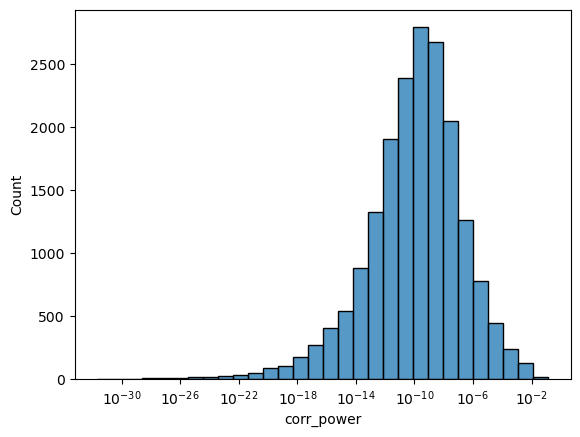

In [49]:
sns.histplot(
    edges['corr_power'],
    log_scale=True,
    bins=30,
)

plt.show()

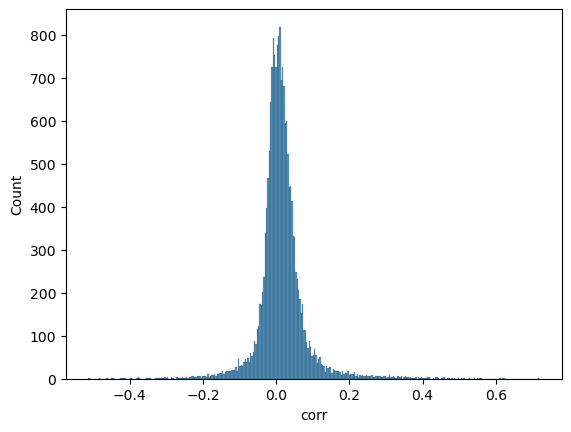

In [51]:
sns.histplot(
    edges['corr'],
    # log_scale=True,
    # bins=30,
)

plt.show()

In [17]:
# PRRX1
edges = pd.DataFrame(sub_GP.edges(), columns=["gene1", "gene2"])
print(edges.shape)
edges.head()


edges["corr"] = [
    RP.loc[g1, g2] if g1 in RP.index and g2 in RP.columns else np.nan
    for g1, g2 in zip(edges["gene1"], edges["gene2"])
]

edges.head()

(3112, 2)


,gene1,gene2,corr
0,PRRX1,COPZ2,0.028781
1,PRRX1,METTL13,-0.031857
2,PRRX1,DCN,0.212929
3,PRRX1,SNAI2,0.013149
4,PRRX1,VIM,0.163227


In [18]:
threshold = 0.1

edges["above_thresh"] = edges["corr"].abs() > threshold

fraction = (edges["corr"].abs() > threshold).mean(skipna=True)
# fraction = edges["above_thresh"].mean()
print(fraction)

0.2191516709511568


In [19]:
edges.head()

,gene1,gene2,corr,above_thresh
0,PRRX1,COPZ2,0.028781,False
1,PRRX1,METTL13,-0.031857,False
2,PRRX1,DCN,0.212929,True
3,PRRX1,SNAI2,0.013149,False
4,PRRX1,VIM,0.163227,True


In [36]:
adata.X = adata.layers['log_norm'].copy()

gene_list = ['MYOD1', 'PRRX1']


mdata = adata[:, gene_list].copy()
print(mdata.shape)

X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

X_df = pd.DataFrame(
    X,
    index=mdata.obs_names,
    columns=mdata.var_names,
)

print(X_df.shape)
X_df.head()

(16296, 2)
(16296, 2)


gene_name,MYOD1,PRRX1
AAACCAAAGCAACTGC_hybrid,2.306209,0.000000
AAACCAAAGTAGGGCA_hybrid,1.635624,0.709594
AAACCAAAGTCTAGGC_hybrid,1.135698,0.301751
AAACCATTCACGTAAT_hybrid,0.000000,0.000000
AAACCATTCAGGCAGA_hybrid,0.000000,0.433809


In [37]:
tmp = adata.obs[['pooled_condition']].copy()
tmp.head()

,pooled_condition
AAACCAAAGCAACTGC_hybrid,siPRRX1/mmMYOD1
AAACCAAAGTAGGGCA_hybrid,mmMYOD1
AAACCAAAGTCTAGGC_hybrid,siPRRX1/mmMYOD1
AAACCATTCACGTAAT_hybrid,siPRRX1
AAACCATTCAGGCAGA_hybrid,siPRRX1


In [40]:
X_df = X_df.merge(tmp, how='left', left_index=True, right_index=True)
print(X_df.shape)
X_df.head()

(16296, 3)


,MYOD1,PRRX1,pooled_condition
AAACCAAAGCAACTGC_hybrid,2.306209,0.000000,siPRRX1/mmMYOD1
AAACCAAAGTAGGGCA_hybrid,1.635624,0.709594,mmMYOD1
AAACCAAAGTCTAGGC_hybrid,1.135698,0.301751,siPRRX1/mmMYOD1
AAACCATTCACGTAAT_hybrid,0.000000,0.000000,siPRRX1
AAACCATTCAGGCAGA_hybrid,0.000000,0.433809,siPRRX1


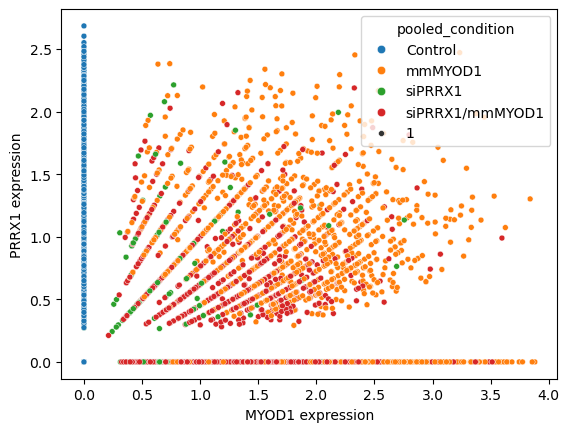

In [42]:
gene_i = 'MYOD1'
gene_j = 'PRRX1'


sns.scatterplot(
    data=X_df,
    x='MYOD1',
    y='PRRX1',
    hue='pooled_condition',
    size=1,
)




# exp_i = X_df[gene_i]
# print(exp_i.shape)

# exp_j = X_df[gene_j]


# plt.scatter(
#     x=exp_i,
#     y=exp_j,
#     s=1
# )

plt.xlabel(f"{gene_i} expression")
plt.ylabel(f"{gene_j} expression")

plt.show()